# **Stroke Dataset** 

## METHOD 1. **Logistic Regression with Evaluation**

In [3]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

stroke_df = pd.read_csv("stroke_final_label.csv")

# Separate features and target
X = stroke_df.drop(columns='Stroke')
y = stroke_df['Stroke']

# Train-test split with stratification to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train logistic regression with balanced class weights
lr = LogisticRegression(max_iter=1000, class_weight='balanced', solver='liblinear')
lr.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred = lr.predict(X_test_scaled)
y_proba = lr.predict_proba(X_test_scaled)[:, 1]

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
spec = confusion_matrix(y_test, y_pred)[0, 0] / sum(confusion_matrix(y_test, y_pred)[0])
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_proba)

# Output results
print("=== Logistic Regression Evaluation (Stroke) ===")
print(f"Accuracy     : {acc:.4f}")
print(f"Precision    : {prec:.4f}")
print(f"Recall       : {rec:.4f}")
print(f"Specificity  : {spec:.4f}")
print(f"F1 Score     : {f1:.4f}")
print(f"ROC AUC      : {roc:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print("\n=== Confusion Matrix ===")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")
print("\nMatrix Format:")
print("              Predicted No   Predicted Yes")
print(f"Actual No     {tn:>10}       {fp:>10}")
print(f"Actual Yes    {fn:>10}       {tp:>10}")

# Feature Importance (Coefficients)
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr.coef_[0]}).sort_values(by='Coefficient', key=abs, ascending=False)

print("\nTop Contributing Features (Logistic Coefficients):")
print(coef_df.head(10))


=== Logistic Regression Evaluation (Stroke) ===
Accuracy     : 0.6455
Precision    : 0.0871
Recall       : 0.7300
Specificity  : 0.6415
F1 Score     : 0.1556
ROC AUC      : 0.7482

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.64      0.78     60967
           1       0.09      0.73      0.16      2856

    accuracy                           0.65     63823
   macro avg       0.53      0.69      0.47     63823
weighted avg       0.94      0.65      0.75     63823


=== Confusion Matrix ===
True Negatives (TN): 39113
False Positives (FP): 21854
False Negatives (FN): 771
True Positives (TP): 2085

Matrix Format:
              Predicted No   Predicted Yes
Actual No          39113            21854
Actual Yes           771             2085

Top Contributing Features (Logistic Coefficients):
                  Feature  Coefficient
0             AgeCategory     0.870272
8             HadDiabetes     0.193899
4            SmokerStatu

### *Confusion Matrix Plot*

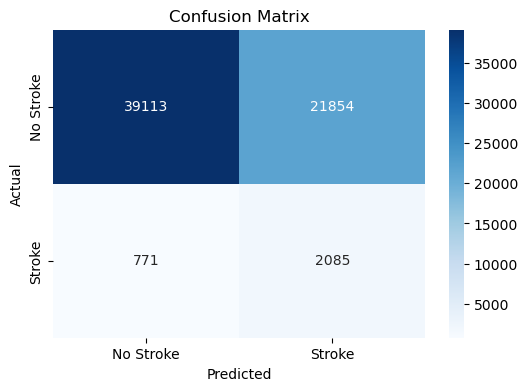

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Stroke', 'Stroke'], yticklabels=['No Stroke', 'Stroke'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## METHOD 2. **Decision Tree Classifier**

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix)

stroke_df = pd.read_csv("stroke_final_label.csv") 

# Separate features and target
X = stroke_df.drop(columns='Stroke')
y = stroke_df['Stroke']

# Train-test split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Decision Tree with class weighting to address imbalance
dt = DecisionTreeClassifier(class_weight='balanced', max_depth=8, random_state=42)
dt.fit(X_train_scaled, y_train)

# Predict
y_pred = dt.predict(X_test_scaled)
y_proba = dt.predict_proba(X_test_scaled)[:, 1]

# Evaluation metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
spec = confusion_matrix(y_test, y_pred)[0, 0] / sum(confusion_matrix(y_test, y_pred)[0])
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_proba)

# Print Evaluation
print("=== Decision Tree Evaluation (Stroke) ===")
print(f"Accuracy     : {acc:.4f}")
print(f"Precision    : {prec:.4f}")
print(f"Recall       : {rec:.4f}")
print(f"Specificity  : {spec:.4f}")
print(f"F1 Score     : {f1:.4f}")
print(f"ROC AUC      : {roc:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix 
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print("\n=== Confusion Matrix ===")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")
print("\nMatrix Format:")
print("              Predicted No   Predicted Yes")
print(f"Actual No     {tn:>10}       {fp:>10}")
print(f"Actual Yes    {fn:>10}       {tp:>10}")

# Feature Importances
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': dt.feature_importances_}).sort_values(by='Importance', ascending=False)
print("\nTop Contributing Features (Decision Tree Importances):")
print(feature_importance.head(10))


=== Decision Tree Evaluation (Stroke) ===
Accuracy     : 0.5969
Precision    : 0.0805
Recall       : 0.7682
Specificity  : 0.5889
F1 Score     : 0.1457
ROC AUC      : 0.7312

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.59      0.74     60967
           1       0.08      0.77      0.15      2856

    accuracy                           0.60     63823
   macro avg       0.53      0.68      0.44     63823
weighted avg       0.94      0.60      0.71     63823


=== Confusion Matrix ===
True Negatives (TN): 35902
False Positives (FP): 25065
False Negatives (FN): 662
True Positives (TP): 2194

Matrix Format:
              Predicted No   Predicted Yes
Actual No          35902            25065
Actual Yes           662             2194

Top Contributing Features (Decision Tree Importances):
               Feature  Importance
0          AgeCategory    0.666503
8          HadDiabetes    0.085673
10        HadArthritis    0.071308
3  

## METHOD 3. **Random Forest**

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix)

stroke_df = pd.read_csv("stroke_final.csv")

# Define Features and Target
X = stroke_df.drop(columns=['Stroke'])
y = stroke_df['Stroke']

# Split into Train/Test Sets 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the model with class_weight='balanced'
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

# Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred)
specificity = confusion_matrix(y_test, y_pred)[0,0] / (confusion_matrix(y_test, y_pred)[0,0] + confusion_matrix(y_test, y_pred)[0,1])
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

# Display Results
print("=== Random Forest Evaluation (Stroke) ===")
print(f"Accuracy     : {accuracy:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"Specificity  : {specificity:.4f}")
print(f"F1 Score     : {f1:.4f}")
print(f"ROC AUC      : {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print("\n=== Confusion Matrix ===")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")

print("\nMatrix Format:")
print(f"{'':<20}{'Predicted No':<15}{'Predicted Yes'}")
print(f"{'Actual No':<20}{tn:<15}{fp}")
print(f"{'Actual Yes':<20}{fn:<15}{tp}")

# Feature Importances
importances = rf.feature_importances_
feature_names = X_train.columns
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

print("\nTop Contributing Features (Random Forest Importances):")
print(feature_imp_df.head(10))


=== Random Forest Evaluation (Stroke) ===
Accuracy     : 0.9422
Precision    : 0.0573
Recall       : 0.0189
Specificity  : 0.9854
F1 Score     : 0.0284
ROC AUC      : 0.6527

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97     60967
           1       0.06      0.02      0.03      2856

    accuracy                           0.94     63823
   macro avg       0.51      0.50      0.50     63823
weighted avg       0.92      0.94      0.93     63823


=== Confusion Matrix ===
True Negatives (TN): 60078
False Positives (FP): 889
False Negatives (FN): 2802
True Positives (TP): 54

Matrix Format:
                    Predicted No   Predicted Yes
Actual No           60078          889
Actual Yes          2802           54

Top Contributing Features (Random Forest Importances):
                        Feature  Importance
0                           BMI    0.374685
1                    SleepHours    0.118124
2              

## METHOD 4. **LightGBM Threshold Tuning (0.10 – 0.60) + Visualization**

[LightGBM] [Info] Number of positive: 243866, number of negative: 243866
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.138045 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5054
[LightGBM] [Info] Number of data points in the train set: 487732, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[15]	valid_0's auc: 0.726484	valid_0's binary_logloss: 0.535647

=== Best Threshold Based on F1 Score ===
Threshold      0.520000
Accuracy       0.848566
Precision      0.113169
Recall         0.348739
Specificity    0.871980
F1 Score       0.170884
Name: 32, dtype: float64


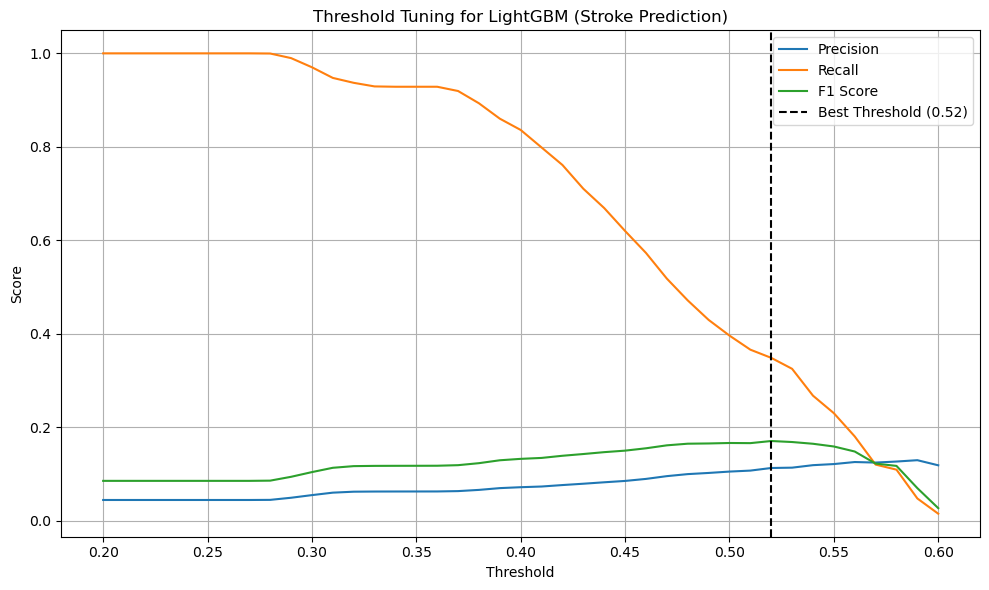


=== LightGBM Final Evaluation (Stroke Dataset) ===
Threshold    : 0.52
Accuracy     : 0.8486
Precision    : 0.1132
Recall       : 0.3487
Specificity  : 0.8720
F1 Score     : 0.1709
ROC AUC      : 0.7265

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.87      0.92     60967
           1       0.11      0.35      0.17      2856

    accuracy                           0.85     63823
   macro avg       0.54      0.61      0.54     63823
weighted avg       0.93      0.85      0.88     63823


=== Confusion Matrix ===
True Negatives (TN): 53162
False Positives (FP): 7805
False Negatives (FN): 1860
True Positives (TP): 996

Matrix Format:
                    Predicted No   Predicted Yes
Actual No           53162          7805
Actual Yes          1860           996

Top Contributing Features (LightGBM Importances):
                        Feature  Importance
1                    SleepHours         174
14  AgeCategory_Age 80 or olde

In [2]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report)
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings("ignore")  # Suppress metric warnings for undefined precision

# Load dataset
stroke_df = pd.read_csv("stroke_final.csv")

# Define features and target
X = stroke_df.drop(columns=['Stroke'])
y = stroke_df['Stroke']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y,
                                                    test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply SMOTE to balance training data
sm = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train_scaled, y_train)

# Train LightGBM
model = lgb.LGBMClassifier(objective='binary', is_unbalance=False,
                           learning_rate=0.05, num_leaves=31, n_estimators=100,
                           boosting_type='gbdt', random_state=42)

model.fit(X_train_resampled, y_train_resampled,
          eval_set=[(X_test_scaled, y_test)],
          eval_metric='auc',
          callbacks=[lgb.early_stopping(stopping_rounds=10)])

# Predict probabilities
y_probs = model.predict_proba(X_test_scaled)[:, 1]

# Threshold tuning
thresholds = np.arange(0.2, 0.61, 0.01)
results = []

for threshold in thresholds:
    y_pred = (y_probs >= threshold).astype(int)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred)
    spec = confusion_matrix(y_test, y_pred)[0, 0] / sum(confusion_matrix(y_test, y_pred)[0])
    f1 = f1_score(y_test, y_pred)
    results.append({'Threshold': threshold, 'Accuracy': acc, 'Precision': prec,
                    'Recall': rec, 'Specificity': spec, 'F1 Score': f1})

results_df = pd.DataFrame(results)
best_row = results_df.loc[results_df['F1 Score'].idxmax()]

# Print best threshold info
print("\n=== Best Threshold Based on F1 Score ===")
print(best_row)

# Plot threshold tuning
plt.figure(figsize=(10, 6))
plt.plot(results_df['Threshold'], results_df['Precision'], label='Precision')
plt.plot(results_df['Threshold'], results_df['Recall'], label='Recall')
plt.plot(results_df['Threshold'], results_df['F1 Score'], label='F1 Score')
plt.axvline(best_row['Threshold'], color='black', linestyle='--',
            label=f"Best Threshold ({best_row['Threshold']:.2f})")
plt.title("Threshold Tuning for LightGBM (Stroke Prediction)")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Final evaluation with best threshold
final_threshold = best_row['Threshold']
y_pred_final = (y_probs >= final_threshold).astype(int)

# Calculate metrics
acc = accuracy_score(y_test, y_pred_final)
prec = precision_score(y_test, y_pred_final, zero_division=0)
rec = recall_score(y_test, y_pred_final)
spec = confusion_matrix(y_test, y_pred_final)[0, 0] / sum(confusion_matrix(y_test, y_pred_final)[0])
f1 = f1_score(y_test, y_pred_final)
auc = roc_auc_score(y_test, y_probs)

print("\n=== LightGBM Final Evaluation (Stroke Dataset) ===")
print(f"Threshold    : {final_threshold:.2f}")
print(f"Accuracy     : {acc:.4f}")
print(f"Precision    : {prec:.4f}")
print(f"Recall       : {rec:.4f}")
print(f"Specificity  : {spec:.4f}")
print(f"F1 Score     : {f1:.4f}")
print(f"ROC AUC      : {auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_final, zero_division=0))

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_final).ravel()
print("\n=== Confusion Matrix ===")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")

print("\nMatrix Format:")
print(f"{'':<20}{'Predicted No':<15}{'Predicted Yes'}")
print(f"{'Actual No':<20}{tn:<15}{fp}")
print(f"{'Actual Yes':<20}{fn:<15}{tp}")

# Feature importances
feature_imp_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nTop Contributing Features (LightGBM Importances):")
print(feature_imp_df.head(10))


## Method 5. **XGBoost + (ROC and PR Curve)**


=== Best Threshold Based on F1 Score ===
Threshold      0.460000
Accuracy       0.842314
Precision      0.110967
Recall         0.359944
Specificity    0.864911
F1 Score       0.169637
Name: 36, dtype: float64

=== XGBoost Final Evaluation (Stroke Dataset) ===
Threshold    : 0.46
Accuracy     : 0.8423
Precision    : 0.1110
Recall       : 0.3599
Specificity  : 0.8649
F1 Score     : 0.1696
ROC AUC      : 0.7262

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.86      0.91     60967
           1       0.11      0.36      0.17      2856

    accuracy                           0.84     63823
   macro avg       0.54      0.61      0.54     63823
weighted avg       0.93      0.84      0.88     63823


=== Confusion Matrix ===
True Negatives (TN): 52731
False Positives (FP): 8236
False Negatives (FN): 1828
True Positives (TP): 1028

Matrix Format:
                    Predicted No   Predicted Yes
Actual No           52731          82

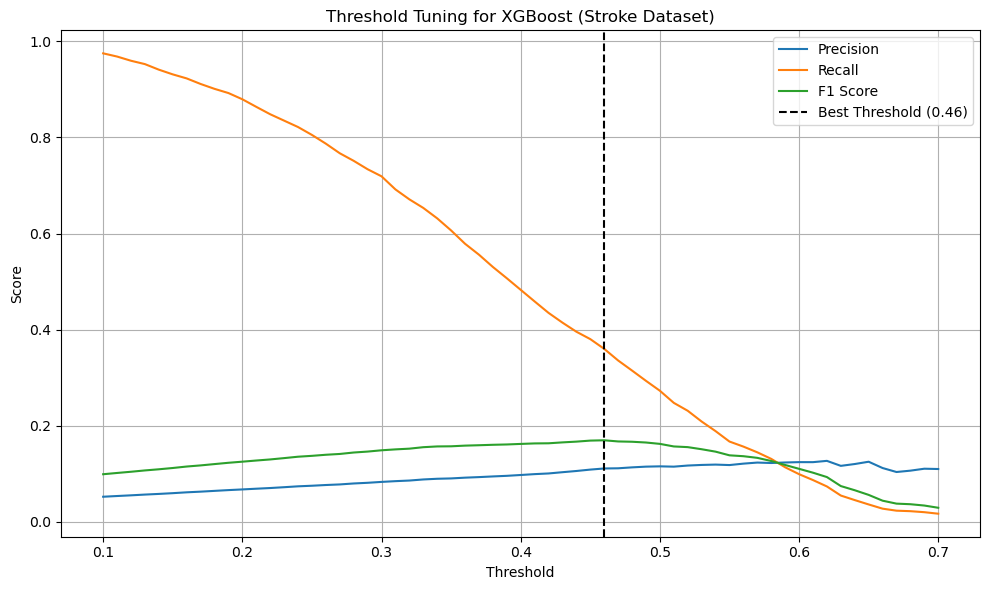

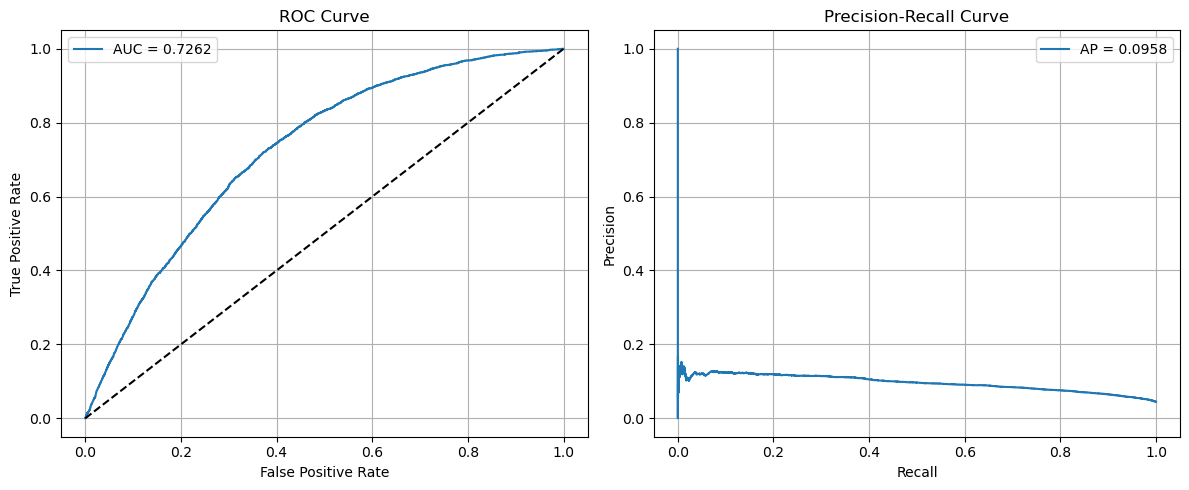

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             roc_curve, precision_recall_curve, average_precision_score)
from imblearn.over_sampling import SMOTE

stroke_df = pd.read_csv("stroke_final.csv")

# Define features and target
X = stroke_df.drop(columns=["Stroke"])
y = stroke_df["Stroke"]

# Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Scale numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply SMOTE
sm = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train_scaled, y_train)

# Initialize XGBoost model
xgb_model = xgb.XGBClassifier(objective='binary:logistic',
                              eval_metric='auc',
                              learning_rate=0.05,
                              n_estimators=100,
                              max_depth=5,
                              scale_pos_weight=1,  # already balanced via SMOTE
                              random_state=42,
                              use_label_encoder=False)

# Train
xgb_model.fit(X_train_resampled, y_train_resampled)

# Predict probabilities
y_probs = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Threshold tuning
thresholds = np.arange(0.1, 0.71, 0.01)
results = []

for thresh in thresholds:
    y_pred = (y_probs >= thresh).astype(int)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    spec = confusion_matrix(y_test, y_pred)[0,0] / sum(confusion_matrix(y_test, y_pred)[0])
    results.append({'Threshold': thresh, 'Accuracy': acc, 'Precision': prec,
                    'Recall': rec, 'Specificity': spec, 'F1 Score': f1})

results_df = pd.DataFrame(results)
best_row = results_df.loc[results_df['F1 Score'].idxmax()]

# Print best threshold
print("\n=== Best Threshold Based on F1 Score ===")
print(best_row)

# Final evaluation
final_thresh = best_row['Threshold']
y_pred_final = (y_probs >= final_thresh).astype(int)

acc = accuracy_score(y_test, y_pred_final)
prec = precision_score(y_test, y_pred_final, zero_division=0)
rec = recall_score(y_test, y_pred_final)
spec = confusion_matrix(y_test, y_pred_final)[0,0] / sum(confusion_matrix(y_test, y_pred_final)[0])
f1 = f1_score(y_test, y_pred_final)
auc = roc_auc_score(y_test, y_probs)

print("\n=== XGBoost Final Evaluation (Stroke Dataset) ===")
print(f"Threshold    : {final_thresh:.2f}")
print(f"Accuracy     : {acc:.4f}")
print(f"Precision    : {prec:.4f}")
print(f"Recall       : {rec:.4f}")
print(f"Specificity  : {spec:.4f}")
print(f"F1 Score     : {f1:.4f}")
print(f"ROC AUC      : {auc:.4f}")

# Classification report and confusion matrix
print("\nClassification Report:")
print(classification_report(y_test, y_pred_final))

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_final).ravel()
print("\n=== Confusion Matrix ===")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")
print("\nMatrix Format:")
print(f"{'':<20}{'Predicted No':<15}{'Predicted Yes'}")
print(f"{'Actual No':<20}{tn:<15}{fp}")
print(f"{'Actual Yes':<20}{fn:<15}{tp}")

# Feature importance
feat_importances = pd.Series(xgb_model.feature_importances_, index=X.columns)
print("\nTop Contributing Features (XGBoost Importances):")
print(feat_importances.sort_values(ascending=False).head(10))

# Plot: Threshold tuning
plt.figure(figsize=(10, 6))
plt.plot(results_df['Threshold'], results_df['Precision'], label='Precision')
plt.plot(results_df['Threshold'], results_df['Recall'], label='Recall')
plt.plot(results_df['Threshold'], results_df['F1 Score'], label='F1 Score')
plt.axvline(final_thresh, color='black', linestyle='--', label=f"Best Threshold ({final_thresh:.2f})")
plt.title("Threshold Tuning for XGBoost (Stroke Dataset)")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ROC and PR curves
fpr, tpr, _ = roc_curve(y_test, y_probs)
precision, recall, _ = precision_recall_curve(y_test, y_probs)
ap = average_precision_score(y_test, y_probs)

plt.figure(figsize=(12, 5))

# ROC Curve
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)

# PR Curve
plt.subplot(1, 2, 2)
plt.plot(recall, precision, label=f"AP = {ap:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
